# HW4 
(آستانه‌گذاری، Mean Shift، Normalized Cut)

In [6]:
import os
import time
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import MeanShift, estimate_bandwidth
from skimage.segmentation import slic
from skimage import graph as skgraph
from skimage.color import label2rgb

%matplotlib inline

IN_DIR = 'Input_Images'
OUT_DIR = 'Output_Images'
for p in ['Part_1','Part_2','Part_3']:
    os.makedirs(OUT_DIR+'/'+p, exist_ok=True)

names = ['BlackPanther.jpg', 'Fish.jpg', 'Horse.jpg']
os.listdir(IN_DIR)

['BlackPanther.jpg', 'Fish.jpg', 'Horse.jpg']

In [7]:
for n in names:
    im = cv2.imread(IN_DIR+'/'+n)
    print(n, im.shape)

BlackPanther.jpg (1146, 1764, 3)
Fish.jpg (900, 1600, 3)
Horse.jpg (3284, 4926, 3)


BlackPanther.jpg (292, 450, 3)
Fish.jpg (253, 450, 3)
Horse.jpg (300, 450, 3)


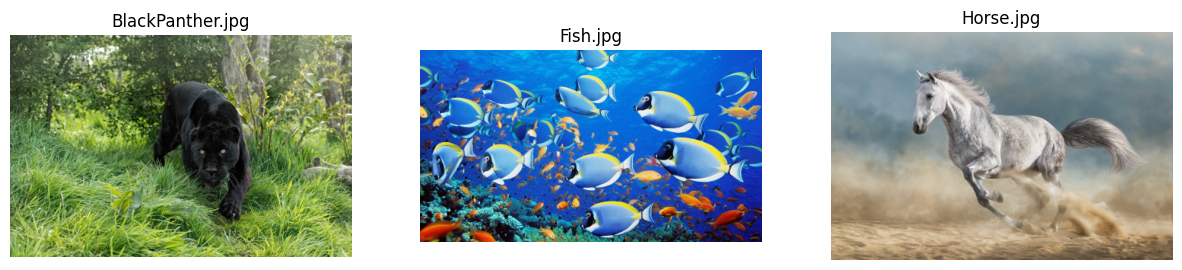

In [8]:
def load_resized(path, max_dim=450):
    im = cv2.imread(path)
    im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    h,w = im.shape[:2]
    scale = max_dim/max(h,w)
    if scale < 1:
        im = cv2.resize(im, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    return im

imgs = {}
for n in names:
    imgs[n] = load_resized(IN_DIR+'/'+n)
    print(n, imgs[n].shape)

plt.figure(figsize=(15,5))
for i,n in enumerate(names):
    plt.subplot(1,3,i+1)
    plt.imshow(imgs[n])
    plt.title(n)
    plt.axis('off')
plt.show()

<div dir="rtl" style="text-align: right;">
قسمت ۱ - آستانه‌گذاری بر اساس هیستوگرام
</div>

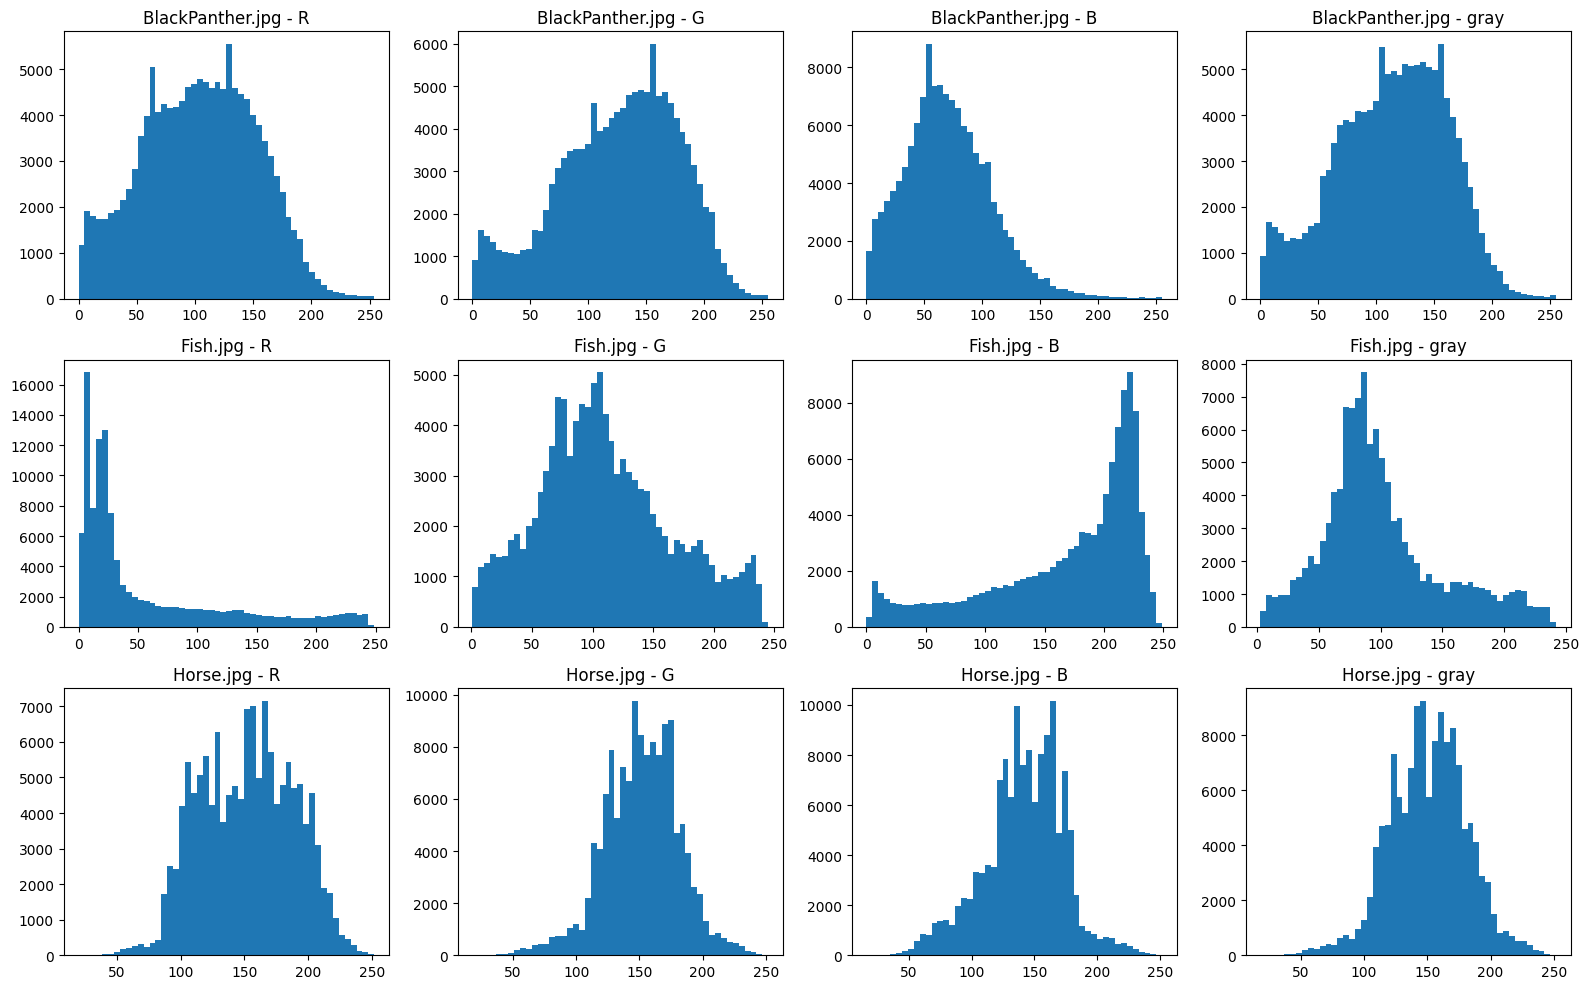

In [9]:
def channels_of(im):
    gray = cv2.cvtColor(im, cv2.COLOR_RGB2GRAY)
    return {'R': im[:,:,0], 'G': im[:,:,1], 'B': im[:,:,2], 'gray': gray}

fig, axes = plt.subplots(3,4, figsize=(16,10))
for i,n in enumerate(names):
    chans = channels_of(imgs[n])
    for j,(cname,ch) in enumerate(chans.items()):
        axes[i,j].hist(ch.ravel(), bins=50)
        axes[i,j].set_title(n+' - '+cname)
plt.tight_layout()
plt.savefig(OUT_DIR+'/Part_1/histograms.png', dpi=100)
plt.show()

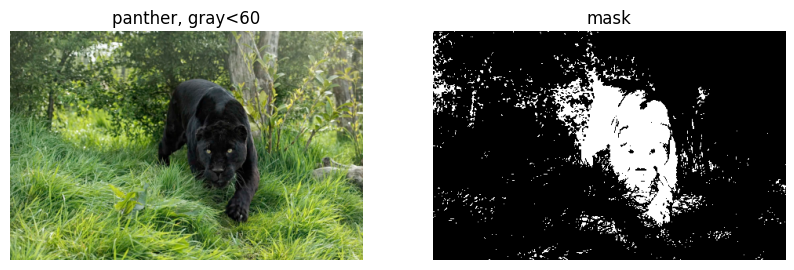

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_thresh(im, mask, title):
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.imshow(im)
    plt.title(title)
    plt.axis('off')
    

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title('Mask')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()


gray_p = channels_of(imgs['BlackPanther.jpg'])['gray']


for t in [40, 60, 80]:
    mask = (gray_p < t).astype(np.uint8) * 255
    path = f"{OUT_DIR}/Part_1/BlackPanther_gray_t{t}.png"
    cv2.imwrite(path, mask)


mask_p = (gray_p < 60).astype(np.uint8) * 255
show_thresh(imgs['BlackPanther.jpg'], mask_p, 'Panther (gray < 60)')

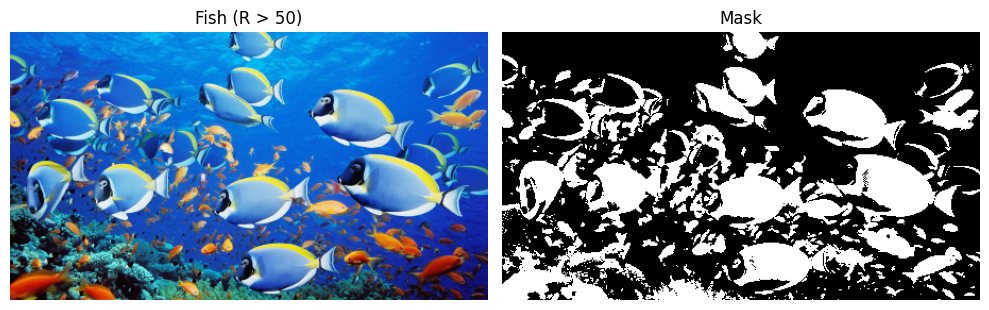

In [ ]:

R_f = channels_of(imgs['Fish.jpg'])['R']


for t in [30, 50, 70]:
    mask = (R_f > t).astype(np.uint8) * 255
    path = f"{OUT_DIR}/Part_1/Fish_R_t{t}.png"
    cv2.imwrite(path, mask)


mask_f = (R_f > 50).astype(np.uint8) * 255
show_thresh(imgs['Fish.jpg'], mask_f, 'Fish (R > 50)')

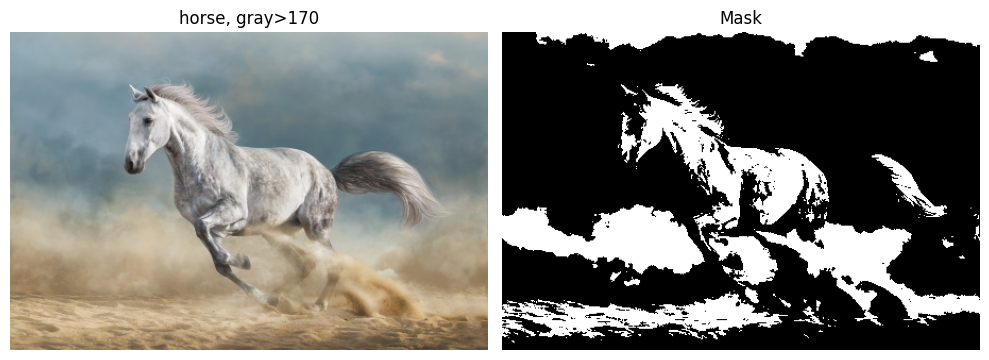

In [ ]:
gray_h = channels_of(imgs['Horse.jpg'])['gray']
for t in [150,170,190]:
    mask = (gray_h > t).astype(np.uint8)*255
    cv2.imwrite(OUT_DIR+f'/Part_1/Horse_gray_t{t}.png', mask)
    
mask_h = (gray_h > 170).astype(np.uint8)*255
show_thresh(imgs['Horse.jpg'], mask_h, 'horse, gray>170')

<div dir="rtl" style="text-align: right;">
 قسمت ۲ - Mean Shift
</div>

In [ ]:
pixels_test = imgs['BlackPanther.jpg'].reshape(-1,3).astype(np.float64)
print(pixels_test.shape)

t0 = time.time()
bw_test = estimate_bandwidth(pixels_test, quantile=0.1, n_samples=500)
ms_test = MeanShift(bandwidth=bw_test, bin_seeding=True)
ms_test.fit(pixels_test)
print('fit on all pixels took', time.time()-t0, 'sec')

(131400, 3)
fit on all pixels took 68.63599467277527 sec


In [ ]:
def meanshift_seg(im, quantile=0.1, n_sample_fit=8000, seed=0):
    pixels = im.reshape(-1,3).astype(np.float64)
    rng = np.random.RandomState(seed)
    idx = rng.choice(pixels.shape[0], size=min(n_sample_fit, pixels.shape[0]), replace=False)
    sample = pixels[idx]
    bw = estimate_bandwidth(sample, quantile=quantile, n_samples=500)
    ms = MeanShift(bandwidth=bw, bin_seeding=True)
    ms.fit(sample)
    centers = ms.cluster_centers_

    dists = np.linalg.norm(pixels[:,None,:]-centers[None,:,:], axis=2)
    labels = np.argmin(dists, axis=1)
    return labels.reshape(im.shape[:2]), centers, bw

t0 = time.time()
labels_test, centers_test, bw_test2 = meanshift_seg(imgs['BlackPanther.jpg'], quantile=0.1)
print('subsample approach took', time.time()-t0, 'sec, bandwidth=', bw_test2, 'n clusters=', len(centers_test))

subsample approach took 4.89672327041626 sec, bandwidth= 31.729317998140953 n clusters= 4


In [15]:
ms_results = {}
for n in names:
    print(n)
    for q in [0.05, 0.1, 0.2]:
        labels, centers, bw = meanshift_seg(imgs[n], quantile=q)
        ms_results[(n,q)] = (labels, centers, bw)
        print('  quantile=',q,' bandwidth=',round(bw,1),' n_clusters=',len(centers))

BlackPanther.jpg
  quantile= 0.05  bandwidth= 22.5  n_clusters= 8
  quantile= 0.1  bandwidth= 31.7  n_clusters= 4
  quantile= 0.2  bandwidth= 45.7  n_clusters= 1
Fish.jpg
  quantile= 0.05  bandwidth= 35.2  n_clusters= 21
  quantile= 0.1  bandwidth= 51.0  n_clusters= 6
  quantile= 0.2  bandwidth= 74.1  n_clusters= 3
Horse.jpg
  quantile= 0.05  bandwidth= 16.5  n_clusters= 12
  quantile= 0.1  bandwidth= 24.8  n_clusters= 4
  quantile= 0.2  bandwidth= 37.2  n_clusters= 2


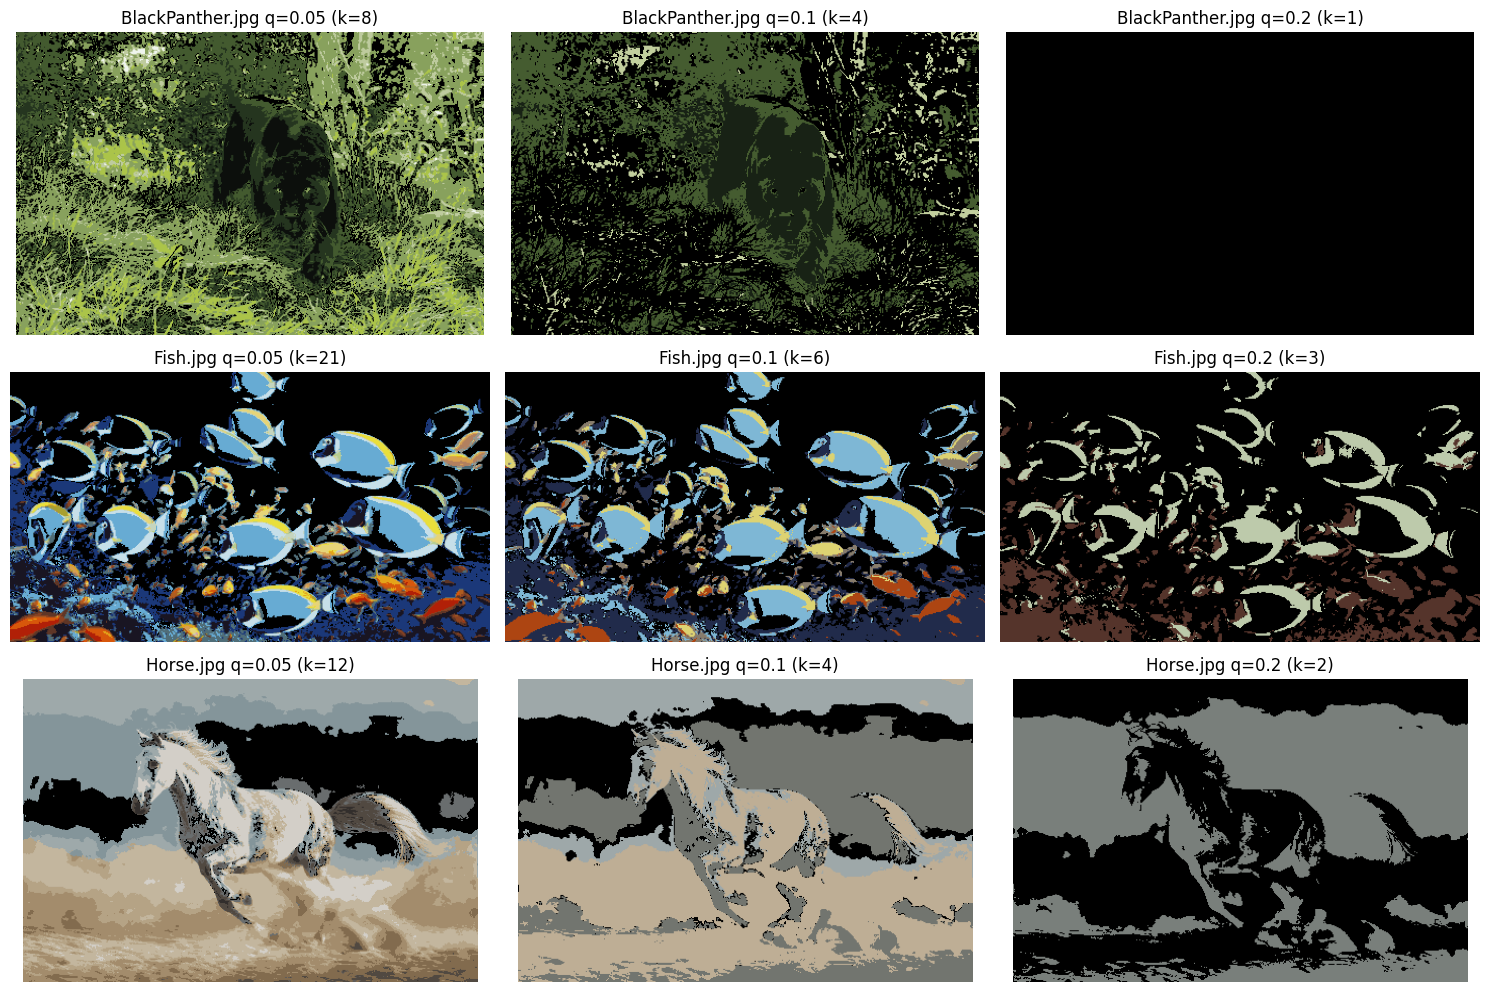

In [16]:
plt.figure(figsize=(15,10))
i=1
for n in names:
    for q in [0.05,0.1,0.2]:
        labels, centers, bw = ms_results[(n,q)]
        out = label2rgb(labels, imgs[n], kind='avg')
        plt.subplot(3,3,i)
        plt.imshow(out)
        plt.title(n+f' q={q} (k={len(centers)})')
        plt.axis('off')
        i+=1
plt.tight_layout()
plt.show()

In [17]:
final_q = {'BlackPanther.jpg': 0.05, 'Fish.jpg': 0.1, 'Horse.jpg': 0.1}
ms_time = {}
for n in names:
    t0 = time.time()
    labels, centers, bw = meanshift_seg(imgs[n], quantile=final_q[n])
    ms_time[n] = time.time()-t0
    out = label2rgb(labels, imgs[n], kind='avg')
    cv2.imwrite(OUT_DIR+f'/Part_2/{n.split(".")[0]}_meanshift.png', cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
    print(n, 'final quantile', final_q[n], 'bandwidth', round(bw,1), 'time', round(ms_time[n],2))

BlackPanther.jpg final quantile 0.05 bandwidth 22.5 time 7.17
Fish.jpg final quantile 0.1 bandwidth 51.0 time 2.26
Horse.jpg final quantile 0.1 bandwidth 24.8 time 5.55



<div dir="rtl" style="text-align: right;">
 قسمت ۳ - Normalized Cut
</div>

In [ ]:
from skimage.util import img_as_float

segs_test = slic(img_as_float(imgs['BlackPanther.jpg']), n_segments=300, compactness=20, start_label=1)
rag_test = skgraph.rag_mean_color(img_as_float(imgs['BlackPanther.jpg']), segs_test, mode='similarity')
labels_test2 = skgraph.cut_normalized(segs_test, rag_test)
print('n clusters:', len(np.unique(labels_test2)))

n clusters: 1


In [19]:
segs_test2 = slic(imgs['BlackPanther.jpg'], n_segments=300, compactness=20, start_label=1)
rag_test2 = skgraph.rag_mean_color(imgs['BlackPanther.jpg'], segs_test2, mode='similarity')
labels_test3 = skgraph.cut_normalized(segs_test2, rag_test2)
print('n clusters:', len(np.unique(labels_test3)))

n clusters: 21


In [20]:
ncut_time = {}
for n in names:
    t0 = time.time()
    segs = slic(imgs[n], n_segments=300, compactness=20, start_label=1)
    rag = skgraph.rag_mean_color(imgs[n], segs, mode='similarity')
    try:
        labels = skgraph.cut_normalized(segs, rag, thresh=0.001)
        ncut_time[n] = time.time()-t0
        print(n, 'OK, time', round(ncut_time[n],2), 'n clusters', len(np.unique(labels)))
    except Exception as e:
        print(n, 'FAILED:', repr(e))

BlackPanther.jpg OK, time 2.78 n clusters 21
Fish.jpg FAILED: ArpackError('ARPACK error 3: No shifts could be applied during a cycle of the Implicitly restarted Arnoldi iteration. One possibility is to increase the size of NCV relative to NEV. ')
Horse.jpg OK, time 3.04 n clusters 11


In [21]:
ncut_time = {}
ncut_labels = {}
for n in names:
    t0 = time.time()
    segs = slic(imgs[n], n_segments=250, compactness=20, start_label=1)
    rag = skgraph.rag_mean_color(imgs[n], segs, mode='similarity')
    labels = skgraph.cut_normalized(segs, rag, thresh=0.001)
    ncut_time[n] = time.time()-t0
    ncut_labels[n] = labels
    out = label2rgb(labels, imgs[n], kind='avg', bg_label=0)
    cv2.imwrite(OUT_DIR+f'/Part_3/{n.split(".")[0]}_ncut.png', cv2.cvtColor(out, cv2.COLOR_RGB2BGR))
    print(n, 'time', round(ncut_time[n],2), 'n clusters', len(np.unique(labels)))

BlackPanther.jpg time 3.18 n clusters 18
Fish.jpg time 2.42 n clusters 42
Horse.jpg time 2.01 n clusters 11


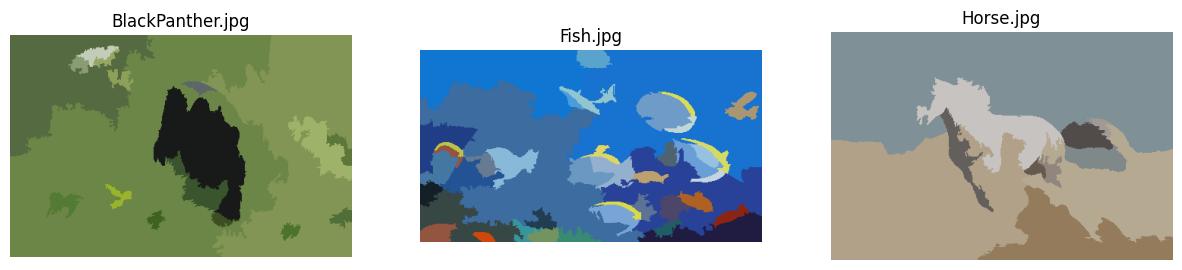

In [22]:
plt.figure(figsize=(15,5))
for i,n in enumerate(names):
    out = label2rgb(ncut_labels[n], imgs[n], kind='avg', bg_label=0)
    plt.subplot(1,3,i+1)
    plt.imshow(out)
    plt.title(n)
    plt.axis('off')
plt.show()